# XGBoost — Wind power forecasting

Ce notebook entraîne un modèle **XGBoost** en respectant la logique de ton notebook `wind_forecast_vf.ipynb` :

- chargement des **parquets déjà créés** ;
- reconstruction correcte de la **CV temporelle expanding-window** ;
- entraînement fold par fold avec **early stopping** ;
- réentraînement final sur tout le train ;
- évaluation finale avec **MAE, RMSE, nRMSE** (même définition que dans ton notebook).

> Important : pour reconstruire correctement la CV, il faut connaître `delivery_time` sur le train.  
> Si `data/train_delivery_time.parquet` n'existe pas encore, une cellule plus bas te donne le code exact à exécuter dans le notebook de preprocessing.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


## 1. Chargement des parquets

In [2]:
DATA_DIR = Path("data")

X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet")
X_test  = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_test  = pd.read_parquet(DATA_DIR / "y_test.parquet")

# y may be saved as a single-column dataframe
if isinstance(y_train, pd.DataFrame):
    assert y_train.shape[1] == 1, "y_train doit contenir une seule colonne"
    TARGET = y_train.columns[0]
    y_train = y_train.iloc[:, 0]
else:
    TARGET = "capacity_factor"

if isinstance(y_test, pd.DataFrame):
    assert y_test.shape[1] == 1, "y_test doit contenir une seule colonne"
    y_test = y_test.iloc[:, 0]

FEATURE_COLS = list(X_train.columns)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape} | target = {TARGET}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")
print(f"Nombre de features: {len(FEATURE_COLS)}")


X_train: (248304, 83)
y_train: (248304,) | target = capacity_factor
X_test : (26390, 83)
y_test : (26390,)
Nombre de features: 83


## 2. Chargement des timestamps train/test pour reconstruire la CV temporelle

In [4]:
train_time_path = DATA_DIR / "train_delivery_time.parquet"
test_time_path  = DATA_DIR / "test_delivery_time.parquet"

if train_time_path.exists() and test_time_path.exists():
    train_delivery_time = pd.read_parquet(train_time_path)
    test_delivery_time  = pd.read_parquet(test_time_path)

    # support either Series-like or DataFrame with one column
    if isinstance(train_delivery_time, pd.DataFrame):
        if "delivery_time" in train_delivery_time.columns:
            train_delivery_time = train_delivery_time["delivery_time"]
        else:
            train_delivery_time = train_delivery_time.iloc[:, 0]

    if isinstance(test_delivery_time, pd.DataFrame):
        if "delivery_time" in test_delivery_time.columns:
            test_delivery_time = test_delivery_time["delivery_time"]
        else:
            test_delivery_time = test_delivery_time.iloc[:, 0]

    train_delivery_time = pd.to_datetime(train_delivery_time, utc=True)
    test_delivery_time  = pd.to_datetime(test_delivery_time, utc=True)

    print("Timestamps chargés depuis :")
    print(f"  - {train_time_path}")
    print(f"  - {test_time_path}")
else:
    raise FileNotFoundError(
        "Impossible de reconstruire la CV temporelle :\n"
        "- il manque data/train_delivery_time.parquet et/ou data/test_delivery_time.parquet.\n\n"
        )

assert len(train_delivery_time) == len(X_train), "train_delivery_time n'a pas la même longueur que X_train"
assert len(test_delivery_time) == len(X_test), "test_delivery_time n'a pas la même longueur que X_test"

print(f"Train time: {train_delivery_time.min()} -> {train_delivery_time.max()}")
print(f"Test  time: {test_delivery_time.min()} -> {test_delivery_time.max()}")


Timestamps chargés depuis :
  - data\train_delivery_time.parquet
  - data\test_delivery_time.parquet
Train time: 2023-01-01 00:00:00+00:00 -> 2025-10-31 23:00:00+00:00
Test  time: 2025-11-01 00:00:00+00:00 -> 2026-02-18 22:00:00+00:00


## 3. Reconstruction fidèle de la CV temporelle

In [5]:
TEST_START = pd.Timestamp("2025-11-01 00:00", tz="UTC")
N_SPLITS = 6
VAL_DAYS = 90
VAL_DURATION = pd.Timedelta(days=VAL_DAYS)

# Vérification de cohérence avec le split du notebook source
assert (train_delivery_time < TEST_START).all(), "Le train contient des timestamps >= TEST_START"
assert (test_delivery_time >= TEST_START).all(), "Le test contient des timestamps < TEST_START"

max_time = train_delivery_time.max()

fold_info = []
fold_indices = []

print(f"CV folds ({N_SPLITS} folds, {VAL_DAYS}-day validation windows):")

for fold in range(N_SPLITS):
    val_end = max_time - fold * VAL_DURATION
    val_start = val_end - VAL_DURATION

    train_mask = train_delivery_time < val_start
    val_mask   = (train_delivery_time >= val_start) & (train_delivery_time < val_end)

    tr_idx = np.where(train_mask.to_numpy())[0]
    val_idx = np.where(val_mask.to_numpy())[0]

    if len(tr_idx) == 0 or len(val_idx) == 0:
        continue

    t_start = train_delivery_time.iloc[tr_idx].min().date()
    t_end   = train_delivery_time.iloc[tr_idx].max().date()
    v_start = train_delivery_time.iloc[val_idx].min().date()
    v_end   = train_delivery_time.iloc[val_idx].max().date()

    fold_info.append((t_start, t_end, v_start, v_end))
    fold_indices.append((tr_idx, val_idx))

    print(f"  Fold {len(fold_info)}: train {t_start} → {t_end} | val {v_start} → {v_end}")

print(f"\nNombre de folds réellement utilisables : {len(fold_indices)}")


CV folds (6 folds, 90-day validation windows):
  Fold 1: train 2023-01-01 → 2025-08-02 | val 2025-08-02 → 2025-10-31
  Fold 2: train 2023-01-01 → 2025-05-04 | val 2025-05-04 → 2025-08-02
  Fold 3: train 2023-01-01 → 2025-02-03 | val 2025-02-03 → 2025-05-04
  Fold 4: train 2023-01-01 → 2024-11-05 | val 2024-11-05 → 2025-02-03
  Fold 5: train 2023-01-01 → 2024-08-07 | val 2024-08-07 → 2024-11-05
  Fold 6: train 2023-01-01 → 2024-05-09 | val 2024-05-09 → 2024-08-07

Nombre de folds réellement utilisables : 6


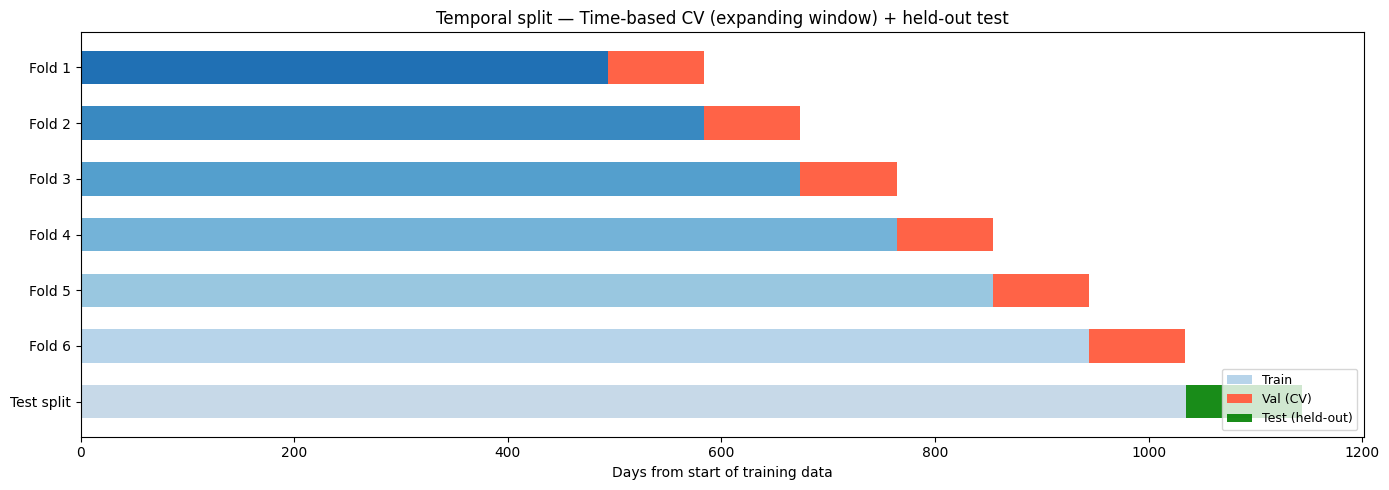

In [6]:
# Visualisation des splits
global_start = train_delivery_time.min()

fig, ax = plt.subplots(figsize=(14, 5))
blues = plt.cm.Blues(np.linspace(0.3, 0.75, len(fold_info)))

for fold_i, (t_start, t_end, v_start, v_end) in enumerate(fold_info, 1):
    t_start = pd.Timestamp(t_start, tz="UTC")
    t_end   = pd.Timestamp(t_end, tz="UTC")
    v_start = pd.Timestamp(v_start, tz="UTC")
    v_end   = pd.Timestamp(v_end, tz="UTC")

    t_left  = (t_start - global_start).days
    t_width = (t_end   - t_start).days

    v_left  = (v_start - global_start).days
    v_width = (v_end   - v_start).days

    ax.barh(fold_i, t_width, left=t_left, height=0.6,
            color=blues[fold_i-1], label="Train" if fold_i == 1 else "")
    ax.barh(fold_i, v_width, left=v_left, height=0.6,
            color="tomato", label="Val (CV)" if fold_i == 1 else "")

test_left = (TEST_START - global_start).days
test_width = max((test_delivery_time.max() - TEST_START).days, 1)

ax.barh(0, test_left, height=0.6, color="steelblue", alpha=0.3)
ax.barh(0, test_width, left=test_left, height=0.6,
        color="green", alpha=0.9, label="Test (held-out)")

ax.set_yticks(range(len(fold_info) + 1))
ax.set_yticklabels(["Test split"] + [f"Fold {i}" for i in range(len(fold_info), 0, -1)])
ax.set_xlabel("Days from start of training data")
ax.set_title("Temporal split — Time-based CV (expanding window) + held-out test")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## 4. Fonction d'évaluation — même définition que dans `wind_forecast_vf.ipynb`

In [7]:
def evaluate(y_true, y_pred, label="Model"):
    """Compute MAE, RMSE, nRMSE (normalised by range of y_true)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-9)  # range-normalised
    print(f"[{label:30s}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}")
    return {"label": label, "MAE": mae, "RMSE": rmse, "nRMSE": nrmse}


## 5. Paramètres XGBoost

In [8]:
xgb_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_estimators": 5000,      # grand max + early stopping
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "rmse",
}

EARLY_STOPPING_ROUNDS = 200
xgb_params


{'objective': 'reg:squarederror',
 'tree_method': 'hist',
 'n_estimators': 5000,
 'learning_rate': 0.03,
 'max_depth': 8,
 'min_child_weight': 5,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'reg_alpha': 0.0,
 'reg_lambda': 1.0,
 'random_state': 42,
 'n_jobs': -1,
 'eval_metric': 'rmse'}

## 6. Entraînement en CV expanding-window

In [9]:
cv_results = []
best_iterations = []
oof_pred = np.full(len(X_train), np.nan, dtype=float)

for i, (tr_idx, val_idx) in enumerate(fold_indices, start=1):
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_val = y_train.iloc[val_idx]

    model = XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    booster = model.get_booster()
    best_iter = getattr(model, "best_iteration", None)
    if best_iter is None:
        best_iter = xgb_params["n_estimators"] - 1

    best_iterations.append(best_iter + 1)

    val_pred = model.predict(X_val)
    oof_pred[val_idx] = val_pred

    metrics = evaluate(y_val, val_pred, label=f"XGBoost Fold {i}")
    metrics["fold"] = i
    metrics["best_iteration"] = best_iter + 1
    metrics["n_train"] = len(tr_idx)
    metrics["n_val"] = len(val_idx)
    cv_results.append(metrics)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


[XGBoost Fold 1                ]  MAE=0.0666  RMSE=0.0993  nRMSE=0.1003
[XGBoost Fold 2                ]  MAE=0.0652  RMSE=0.1016  nRMSE=0.1027
[XGBoost Fold 3                ]  MAE=0.0554  RMSE=0.0830  nRMSE=0.0839
[XGBoost Fold 4                ]  MAE=0.0585  RMSE=0.0877  nRMSE=0.0885
[XGBoost Fold 5                ]  MAE=0.0659  RMSE=0.1052  nRMSE=0.1063
[XGBoost Fold 6                ]  MAE=0.0522  RMSE=0.0807  nRMSE=0.0816


,label,MAE,RMSE,nRMSE,fold,best_iteration,n_train,n_val
0,XGBoost Fold 1,0.066638,0.099277,0.100269,1,5000,226694,21600
1,XGBoost Fold 2,0.065246,0.101595,0.102725,2,5000,205094,21600
2,XGBoost Fold 3,0.055352,0.083028,0.083940,3,5000,183542,21552
3,XGBoost Fold 4,0.058547,0.087681,0.088495,4,5000,161942,21600
4,XGBoost Fold 5,0.065863,0.105176,0.106269,5,5000,140342,21600
5,XGBoost Fold 6,0.052187,0.080722,0.081584,6,5000,118790,21552


In [10]:
print("Résumé CV :")
display(cv_results_df[["fold", "n_train", "n_val", "best_iteration", "MAE", "RMSE", "nRMSE"]])

print("\nMoyenne CV :")
display(cv_results_df[["MAE", "RMSE", "nRMSE", "best_iteration"]].mean().to_frame("mean").T)

print("\nÉcart-type CV :")
display(cv_results_df[["MAE", "RMSE", "nRMSE", "best_iteration"]].std().to_frame("std").T)


Résumé CV :


,fold,n_train,n_val,best_iteration,MAE,RMSE,nRMSE
0,1,226694,21600,5000,0.066638,0.099277,0.100269
1,2,205094,21600,5000,0.065246,0.101595,0.102725
2,3,183542,21552,5000,0.055352,0.083028,0.083940
3,4,161942,21600,5000,0.058547,0.087681,0.088495
4,5,140342,21600,5000,0.065863,0.105176,0.106269
5,6,118790,21552,5000,0.052187,0.080722,0.081584



Moyenne CV :


,MAE,RMSE,nRMSE,best_iteration
mean,0.060639,0.092913,0.09388,5000.0



Écart-type CV :


,MAE,RMSE,nRMSE,best_iteration
std,0.006136,0.010392,0.010503,0.0


In [11]:
# OOF score global sur toutes les fenêtres de validation concaténées
valid_oof_mask = ~np.isnan(oof_pred)
oof_metrics = evaluate(y_train.iloc[valid_oof_mask], oof_pred[valid_oof_mask], label="XGBoost CV OOF")
oof_metrics


[XGBoost CV OOF                ]  MAE=0.0606  RMSE=0.0934  nRMSE=0.0943


{'label': 'XGBoost CV OOF',
 'MAE': 0.06064393984119798,
 'RMSE': np.float64(0.09340428103789625),
 'nRMSE': np.float64(0.09427099062124238)}

## 7. Réentraînement final sur tout le train

In [12]:
final_n_estimators = int(np.median(best_iterations))
print(f"n_estimators final retenu (médiane des best_iteration CV): {final_n_estimators}")

final_params = dict(xgb_params)
final_params["n_estimators"] = final_n_estimators

final_model = XGBRegressor(**final_params)
final_model.fit(X_train, y_train, verbose=False)


n_estimators final retenu (médiane des best_iteration CV): 5000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 8. Évaluation finale sur le held-out test

In [13]:
test_pred = final_model.predict(X_test)

test_metrics = evaluate(y_test, test_pred, label="XGBoost Test")
test_metrics


[XGBoost Test                  ]  MAE=0.0739  RMSE=0.1018  nRMSE=0.1027


{'label': 'XGBoost Test',
 'MAE': 0.07390837489686815,
 'RMSE': np.float64(0.1018042627625807),
 'nRMSE': np.float64(0.1027227445286894)}

In [14]:
results_df = pd.DataFrame([
    {"split": "CV_OOF", **{k: v for k, v in oof_metrics.items() if k != "label"}},
    {"split": "TEST", **{k: v for k, v in test_metrics.items() if k != "label"}},
])
results_df


,split,MAE,RMSE,nRMSE
0,CV_OOF,0.060644,0.093404,0.094271
1,TEST,0.073908,0.101804,0.102723


## 9. Importance des variables

,feature,importance
0,effective_wind_power,0.679820
1,ws100_lead1h,0.082727
2,ws10_lead1h,0.073515
3,ws_10_cubed,0.046886
4,ws_10_sq,0.017019
5,wind_speed_10m,0.013134
6,wind_speed_100m,0.007072
7,ws_100_sq,0.006178
8,gusts_lead1h,0.004165
9,ws100_lag1h,0.002679


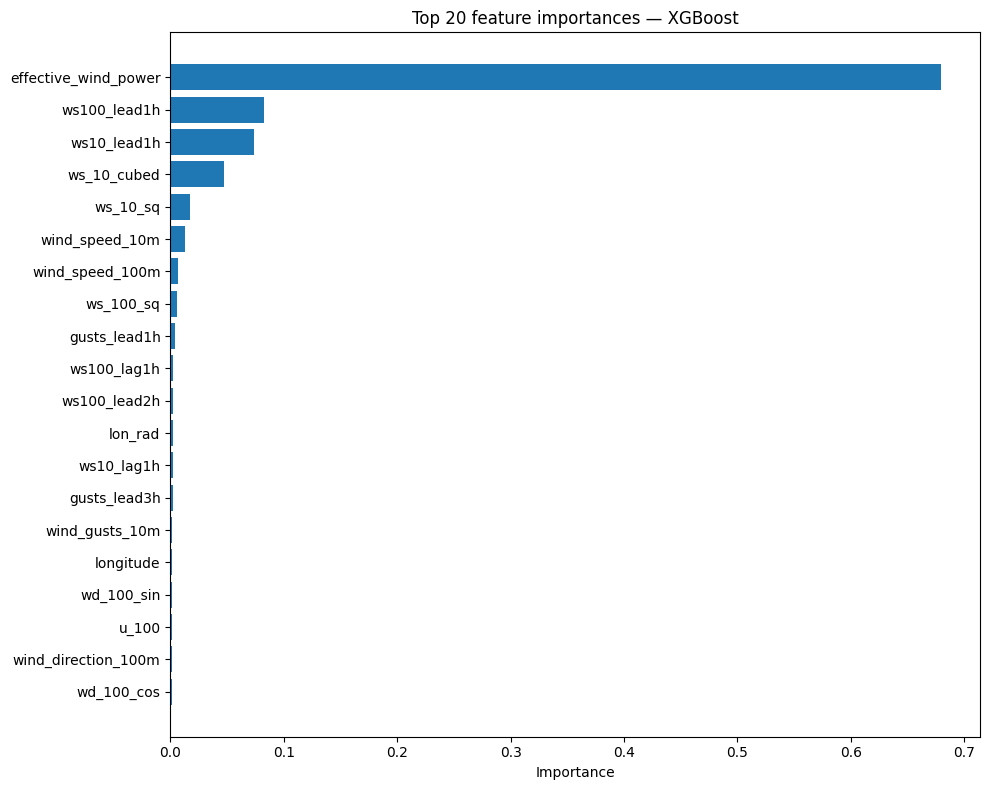

In [15]:
feature_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": final_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(30))

plt.figure(figsize=(10, 8))
top_k = 20
plt.barh(
    feature_importance.loc[:top_k-1, "feature"][::-1],
    feature_importance.loc[:top_k-1, "importance"][::-1],
)
plt.title(f"Top {top_k} feature importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Sauvegarde du modèle et des prédictions

In [ ]:
import joblib

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

joblib.dump(final_model, ARTIFACTS_DIR / "xgboost_wind_model.joblib")

pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "y_pred": test_pred,
    "delivery_time": test_delivery_time.to_numpy(),
}).to_parquet(ARTIFACTS_DIR / "xgboost_test_predictions.parquet", index=False)

cv_results_df.to_parquet(ARTIFACTS_DIR / "xgboost_cv_results.parquet", index=False)

print("Artifacts sauvegardés :")
print(f"  - {ARTIFACTS_DIR / 'xgboost_wind_model.joblib'}")
print(f"  - {ARTIFACTS_DIR / 'xgboost_test_predictions.parquet'}")
print(f"  - {ARTIFACTS_DIR / 'xgboost_cv_results.parquet'}")
